# One-Shard Materialized Validation

This notebook is a comparison variant of `03_one_shard_end_to_end_validation.ipynb`. It validates the same one-shard MVP workflow, but materializes bronze and silver Parquet between stages instead of caching the large intermediate DataFrames.

Because the local Docker notebook runs driver and executor work in one constrained container, this variant also constrains Spark to a low-parallelism local execution profile. That prevents the materialized bronze Parquet read from launching many concurrent Python UDF workers during silver extraction.

In [1]:
from pathlib import Path
import os
import sys


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "src" / "tal_qual").exists():
            return path
    raise RuntimeError("Could not find repository root containing src/tal_qual")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

REPO_ROOT

PosixPath('/home/jovyan/work')

In [2]:
from pyspark.sql import SparkSession
import tempfile
import zipfile

spark = (
    SparkSession.builder
    .master("local[1]")
    .appName("tal-qual-one-shard-materialized-validation")
    .config("spark.default.parallelism", "1")
    .config("spark.sql.shuffle.partitions", "1")
    .config("spark.sql.files.maxPartitionBytes", str(512 * 1024 * 1024))
    .getOrCreate()
)

package_zip = Path(tempfile.gettempdir()) / "tal_qual_src.zip"
with zipfile.ZipFile(package_zip, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for file_path in sorted((SRC_DIR / "tal_qual").rglob("*.py")):
        archive.write(file_path, file_path.relative_to(SRC_DIR))

spark.sparkContext.addPyFile(str(package_zip))

spark.version

'4.1.1'

In [3]:
from time import perf_counter

from tal_qual import (
    BRONZE_OUTPUT_PATH,
    RAW_CORPUS_INPUT,
    SILVER_OUTPUT_PATH,
    connector_family_counts_dataframe,
    pattern_type_counts_dataframe,
    prepare_bronze_dataframe,
    prepare_silver_dataframe,
    sample_examples_dataframe,
    top_vehicles_global_dataframe,
    write_bronze_parquet,
    write_gold_csv_outputs,
    write_silver_parquet,
)

input_path = REPO_ROOT / RAW_CORPUS_INPUT
bronze_output_path = REPO_ROOT / BRONZE_OUTPUT_PATH
silver_output_path = REPO_ROOT / SILVER_OUTPUT_PATH

assert input_path.exists(), f"Missing required one-shard input: {input_path}"

timings = {}

input_path, bronze_output_path, silver_output_path

(PosixPath('/home/jovyan/work/data/raw/brwac-clean-1.txt.gz'),
 PosixPath('/home/jovyan/work/data/bronze/brwac_segments'),
 PosixPath('/home/jovyan/work/data/silver/comparison_candidates'))

## Stage 1: Raw Shard To Bronze Parquet

This stage reads the compressed brWaC shard once, prepares boundary-safe bronze rows, and writes them to Parquet. The downstream stages read the materialized Parquet output instead of reusing an in-memory cache.

In [4]:
start = perf_counter()
bronze_source_df = prepare_bronze_dataframe(spark, input_path)
write_bronze_parquet(bronze_source_df, bronze_output_path)
timings["raw_to_bronze_parquet_seconds"] = perf_counter() - start

start = perf_counter()
bronze_df = spark.read.parquet(str(bronze_output_path))
bronze_count = bronze_df.count()
timings["bronze_parquet_count_seconds"] = perf_counter() - start

bronze_count, timings

(4673057,
 {'raw_to_bronze_parquet_seconds': 48.640892480000275,
  'bronze_parquet_count_seconds': 0.4693520420000823})

## Stage 2: Bronze Parquet To Silver Parquet

This stage extracts silver comparison candidates from the materialized bronze dataset, writes the full silver Parquet output, then rereads silver for counting and aggregation. The bronze read is coalesced to one partition to keep one Python UDF worker active at a time in the Docker notebook container.

In [5]:
start = perf_counter()
bronze_for_silver_df = bronze_df.coalesce(1)
silver_source_df = prepare_silver_dataframe(bronze_for_silver_df)
write_silver_parquet(silver_source_df, silver_output_path)
timings["bronze_to_silver_parquet_seconds"] = perf_counter() - start

start = perf_counter()
silver_df = spark.read.parquet(str(silver_output_path))
candidate_count = silver_df.count()
timings["silver_parquet_count_seconds"] = perf_counter() - start

candidate_count, timings

/usr/local/spark/python/pyspark/sql/udf.py:134: UserWarning: Cannot infer the eval type from type hints. 
  warnings.warn("Cannot infer the eval type from type hints. ", UserWarning)


(58797,
 {'raw_to_bronze_parquet_seconds': 48.640892480000275,
  'bronze_parquet_count_seconds': 0.4693520420000823,
  'bronze_to_silver_parquet_seconds': 69.21684115700009,
  'silver_parquet_count_seconds': 0.11361870900009308})

## Stage 3: Silver Parquet To Gold CSV Outputs

In [6]:
start = perf_counter()
write_gold_csv_outputs(silver_df)
timings["silver_to_gold_csv_seconds"] = perf_counter() - start

timings

{'raw_to_bronze_parquet_seconds': 48.640892480000275,
 'bronze_parquet_count_seconds': 0.4693520420000823,
 'bronze_to_silver_parquet_seconds': 69.21684115700009,
 'silver_parquet_count_seconds': 0.11361870900009308,
 'silver_to_gold_csv_seconds': 3.4781228350002493}

In [7]:
connector_counts_df = connector_family_counts_dataframe(silver_df).cache()
pattern_counts_df = pattern_type_counts_dataframe(silver_df).cache()
top_vehicles_df = top_vehicles_global_dataframe(silver_df).cache()
examples_df = sample_examples_dataframe(silver_df).cache()

connector_counts_pdf = connector_counts_df.toPandas()
pattern_counts_pdf = pattern_counts_df.toPandas()
top_vehicles_pdf = top_vehicles_df.limit(20).toPandas()
examples_pdf = (
    examples_df
    .select(
        "connector_family",
        "pattern_type",
        "candidate_full_text",
        "vehicle_raw",
        "vehicle_normalized",
    )
    .limit(30)
    .toPandas()
)

connector_counts_pdf, pattern_counts_pdf.head(), top_vehicles_pdf.head()

(  connector_family  count
 0             como  47913
 1          que_nem   3912
 2            igual   3268
 3          parecer   1651
 4            feito   1340
 5         tal_qual    608
 6       igualzinho    105,
         pattern_type  count
 0       como_article  33190
 1            como_se  14723
 2       que_nem_bare   3912
 3  igual_preposition   3210
 4    parecer_article   1651,
   vehicle_normalized  occurrence_count  distinct_candidate_text_count
 0               todo              1265                           1254
 1               sabe               337                            190
 2                 vê               306                             78
 3                                  135                            126
 4       não bastasse               105                             28)

## Visualizations

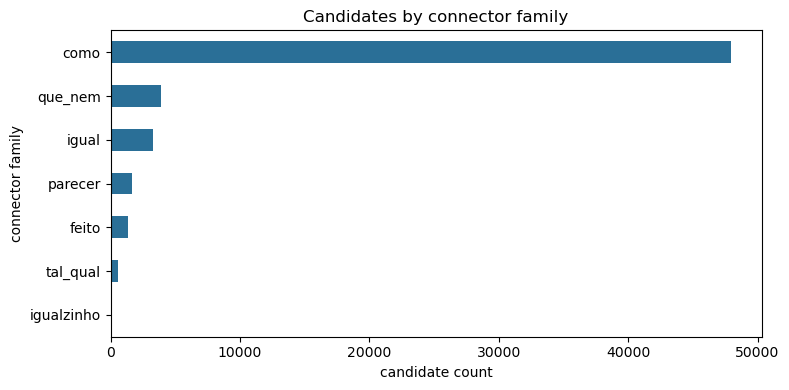

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
connector_counts_pdf.sort_values("count").plot.barh(
    x="connector_family",
    y="count",
    ax=ax,
    legend=False,
    color="#2a6f97",
)
ax.set_title("Candidates by connector family")
ax.set_xlabel("candidate count")
ax.set_ylabel("connector family")
plt.tight_layout()

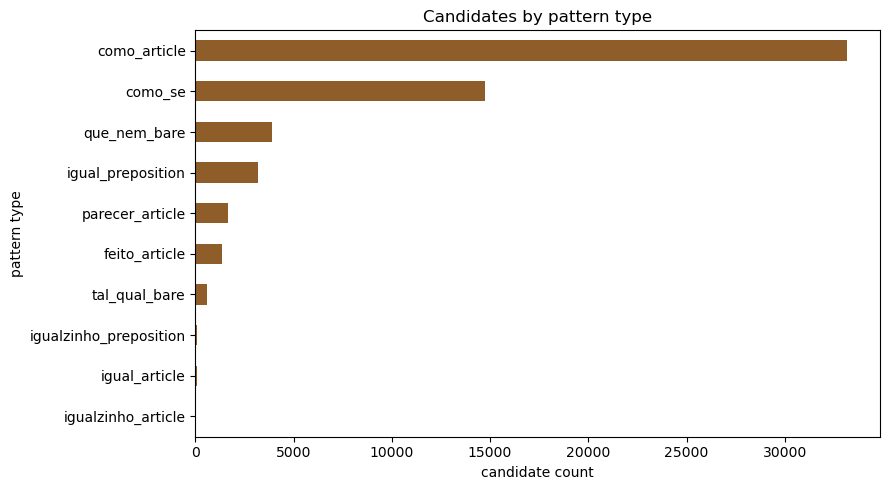

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
pattern_counts_pdf.sort_values("count").plot.barh(
    x="pattern_type",
    y="count",
    ax=ax,
    legend=False,
    color="#8f5d2a",
)
ax.set_title("Candidates by pattern type")
ax.set_xlabel("candidate count")
ax.set_ylabel("pattern type")
plt.tight_layout()

## Candidate Examples

In [10]:
examples_pdf

,connector_family,pattern_type,candidate_full_text,vehicle_raw,vehicle_normalized
0,como,como_article,O Fintas chega em uma mensagem de e-mail como ...,"arquivo anexado de nome ""FF8","arquivo anexado de nome ""ff8"
1,como,como_article,CLUB-K: No inicio da tua carreira o publico br...,rapper controverso sem medo de se dirigir aos ...,rapper controverso sem medo de se dirigir aos ...
2,como,como_article,"Em oito anos no governo, Lula se consolidou co...",fenômeno político graças ao seu apelo junto às...,fenômeno político graças ao seu apelo junto às...
3,como,como_article,Ambos os vasos estão unidos por essa bainha co...,manguito seroso por uma extensão de 4 a 5 cent...,manguito seroso por uma extensão de 4 a 5 cent...
4,como,como_article,"ula mas, por ser atemporal. me traz muitas rec...",doce da infancia que,doce da infancia que
5,como,como_article,Não percebi o personagem principal apenas nem ...,voyeur,voyeur
6,como,como_article,"os de leitura, como costumam dizer os que gost...",fábula,fábula
7,como,como_article,E confirma também a garota Rebecca Hall como u...,atriz de grande talento,atriz de grande talento
8,como,como_article,"tragédia gigantesca, das maiores da História, ...",gemido quase surdo,gemido quase surdo
9,como,como_article,"ndências homossexuais, e talvez esteja mais in...",grande amigo,grande amigo


## Observed Results And Comparison Notes

In [11]:
from IPython.display import Markdown, display

formatted_timings = {key: round(value, 2) for key, value in timings.items()}
top_connectors = connector_counts_pdf.to_dict("records")
top_patterns = pattern_counts_pdf.to_dict("records")
top_vehicles = top_vehicles_pdf.head(10).to_dict("records")

display(Markdown(
    "\n".join([
        f"- Input shard: `{RAW_CORPUS_INPUT}`",
        f"- Bronze segment rows: `{bronze_count:,}`",
        f"- Silver candidate rows: `{candidate_count:,}`",
        f"- Stage timings, seconds: `{formatted_timings}`",
        f"- Connector-family counts: `{top_connectors}`",
        f"- Pattern-type counts: `{top_patterns}`",
        f"- Top normalized vehicles: `{top_vehicles}`",
        "- Comparison note: this variant prefers Parquet materialization plus constrained local parallelism over `.cache()` for the large bronze and silver stages.",
        "- Expected tradeoff: first full run may spend more time on disk I/O, but reruns can restart from bronze or silver without redoing earlier stages.",
        "- Known limitation: extraction is intentionally connector-based and does not classify literal versus figurative usage.",
        "- Known limitation: generic `como` remains excluded, so recall is deliberately lower in exchange for less noise.",
        "- Known limitation: `vehicle_raw` is a bounded right-context phrase, not a syntactic noun phrase or semantic vehicle.",
        "- Feasibility answer: the one-shard run produces enough connector and pattern signal for MVP inspection, so connector-based extraction is feasible on a meaningful brWaC subset.",
    ])
))

- Input shard: `data/raw/brwac-clean-1.txt.gz`
- Bronze segment rows: `4,673,057`
- Silver candidate rows: `58,797`
- Stage timings, seconds: `{'raw_to_bronze_parquet_seconds': 48.64, 'bronze_parquet_count_seconds': 0.47, 'bronze_to_silver_parquet_seconds': 69.22, 'silver_parquet_count_seconds': 0.11, 'silver_to_gold_csv_seconds': 3.48}`
- Connector-family counts: `[{'connector_family': 'como', 'count': 47913}, {'connector_family': 'que_nem', 'count': 3912}, {'connector_family': 'igual', 'count': 3268}, {'connector_family': 'parecer', 'count': 1651}, {'connector_family': 'feito', 'count': 1340}, {'connector_family': 'tal_qual', 'count': 608}, {'connector_family': 'igualzinho', 'count': 105}]`
- Pattern-type counts: `[{'pattern_type': 'como_article', 'count': 33190}, {'pattern_type': 'como_se', 'count': 14723}, {'pattern_type': 'que_nem_bare', 'count': 3912}, {'pattern_type': 'igual_preposition', 'count': 3210}, {'pattern_type': 'parecer_article', 'count': 1651}, {'pattern_type': 'feito_article', 'count': 1340}, {'pattern_type': 'tal_qual_bare', 'count': 608}, {'pattern_type': 'igualzinho_preposition', 'count': 103}, {'pattern_type': 'igual_article', 'count': 58}, {'pattern_type': 'igualzinho_article', 'count': 2}]`
- Top normalized vehicles: `[{'vehicle_normalized': 'todo', 'occurrence_count': 1265, 'distinct_candidate_text_count': 1254}, {'vehicle_normalized': 'sabe', 'occurrence_count': 337, 'distinct_candidate_text_count': 190}, {'vehicle_normalized': 'vê', 'occurrence_count': 306, 'distinct_candidate_text_count': 78}, {'vehicle_normalized': '', 'occurrence_count': 135, 'distinct_candidate_text_count': 126}, {'vehicle_normalized': 'não bastasse', 'occurrence_count': 105, 'distinct_candidate_text_count': 28}, {'vehicle_normalized': 'sociedade das mais desiguais do mundo', 'occurrence_count': 94, 'distinct_candidate_text_count': 1}, {'vehicle_normalized': 'diz', 'occurrence_count': 63, 'distinct_candidate_text_count': 59}, {'vehicle_normalized': '1', 'occurrence_count': 60, 'distinct_candidate_text_count': 59}, {'vehicle_normalized': 'pode ver', 'occurrence_count': 48, 'distinct_candidate_text_count': 13}, {'vehicle_normalized': 'zero', 'occurrence_count': 46, 'distinct_candidate_text_count': 46}]`
- Comparison note: this variant prefers Parquet materialization plus constrained local parallelism over `.cache()` for the large bronze and silver stages.
- Expected tradeoff: first full run may spend more time on disk I/O, but reruns can restart from bronze or silver without redoing earlier stages.
- Known limitation: extraction is intentionally connector-based and does not classify literal versus figurative usage.
- Known limitation: generic `como` remains excluded, so recall is deliberately lower in exchange for less noise.
- Known limitation: `vehicle_raw` is a bounded right-context phrase, not a syntactic noun phrase or semantic vehicle.
- Feasibility answer: the one-shard run produces enough connector and pattern signal for MVP inspection, so connector-based extraction is feasible on a meaningful brWaC subset.